# Exploratory analysis — German solar, weather and price

Reads from the BigQuery `marts` and `staging` layers built by SQLMesh. Cleaning
and feature engineering happen in SQL; this notebook asks whether the result
carries signal and how hard the forecasting problem actually is.

Weather is sampled at nine locations across Germany and comes from archived
*forecasts* at day-ahead lead, not reanalysis — so every feature here was
knowable before the hour it describes.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from smartgrid.config import get_settings
from smartgrid.viz import style
from smartgrid.warehouse import query

style.apply_style()
PROJECT = get_settings().require_project()

mart = query(f"SELECT * FROM `{PROJECT}.marts.mart_solar_features` ORDER BY utc_timestamp")
mart["local_datetime"] = pd.to_datetime(mart["local_datetime"])

print(f"{len(mart):,} hourly rows")
print(f"{mart['utc_timestamp'].min()} to {mart['utc_timestamp'].max()}")

summary_columns = [
    "solar_capacity_factor",
    "ghi_mean",
    "tso_solar_forecast_capacity_factor",
]
mart[summary_columns].describe()

22,632 hourly rows
2024-01-01 00:00:00+00:00 to 2026-07-31 23:00:00+00:00


,solar_capacity_factor,ghi_mean,tso_solar_forecast_capacity_factor
count,22632.000000,22188.000000,22632.000000
mean,0.083794,134.573307,0.087299
std,0.123971,196.617160,0.128262
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.003882,10.777778,0.004529
75%,0.139958,221.250000,0.147806
max,0.519831,867.888889,0.560400


## 1. What solar output looks like

Mean capacity factor across month and hour. A magnitude question, so one hue
from light to dark.

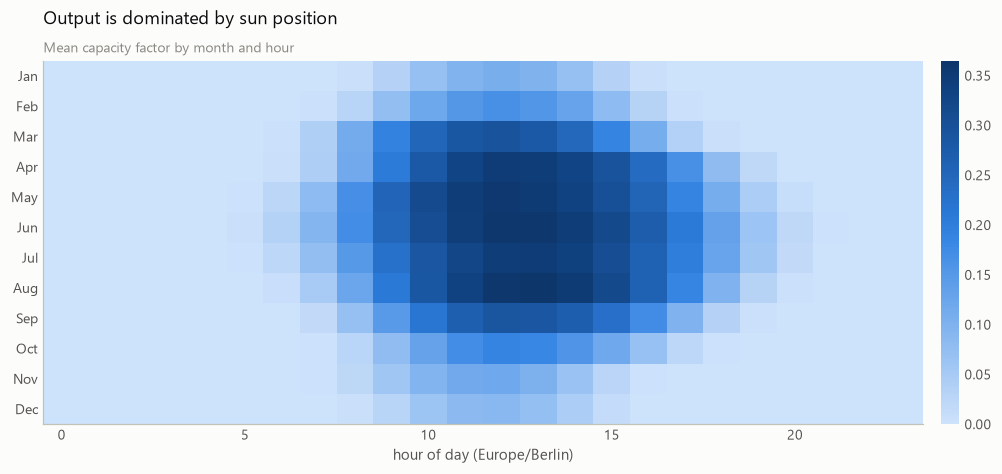

In [2]:
pivot = mart.pivot_table(
    index="month_of_year", columns="hour_of_day",
    values="solar_capacity_factor", aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(9, 4.2))
mesh = ax.pcolormesh(pivot.columns, pivot.index, pivot.to_numpy(),
                     cmap=style.sequential_cmap(), shading="nearest")
ax.set_xlabel("hour of day (Europe/Berlin)")
ax.set_yticks(range(1, 13))
ax.set_yticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.invert_yaxis()
ax.grid(False)
style.titled(ax, "Output is dominated by sun position",
             "Mean capacity factor by month and hour")
bar = fig.colorbar(mesh, ax=ax, pad=0.02)
bar.outline.set_visible(False)
bar.ax.tick_params(length=0, labelsize=9)
style.save(fig, "solar_capacity_factor_heatmap")
plt.show()

The surface is almost entirely determined by where the sun is. A model gets
that from calendar features for free. The forecasting problem lives in the
deviation from it — which is weather.

## 2. Why the target is normalised

Installed capacity keeps climbing, so raw megawatts carry a deployment trend
unrelated to weather.

Three stacked panels rather than a dual axis: aligning two y-scales invents a
relationship whose strength depends on where the axes are pinned.

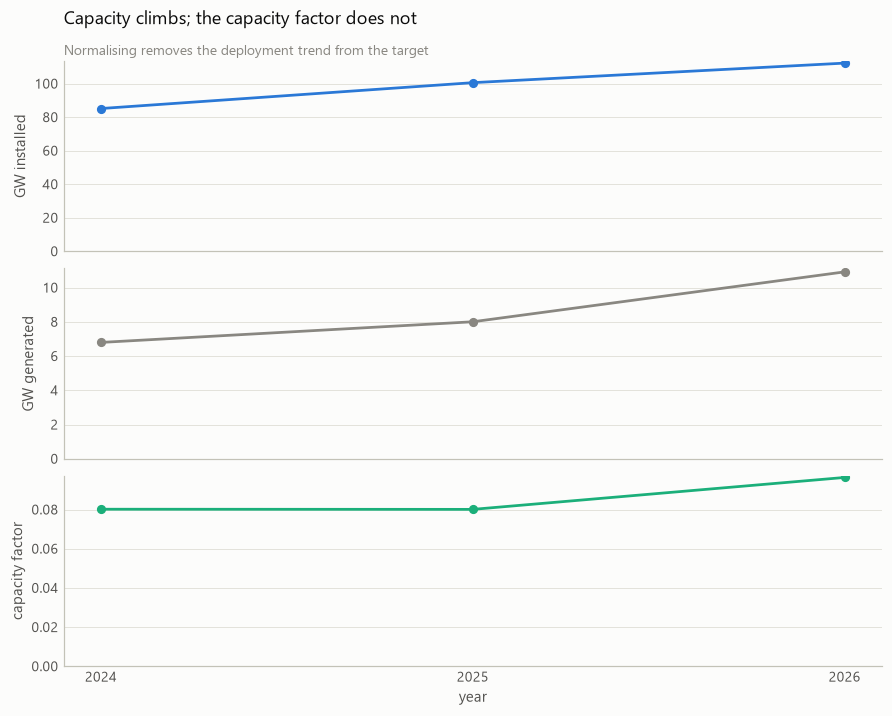

                capacity_gw  generation_gw  capacity_factor
local_datetime                                             
2024                85.1599         6.7980           0.0802
2025               100.5874         8.0050           0.0801
2026               112.2569        10.9197           0.0964


In [3]:
yearly = mart.groupby(mart["local_datetime"].dt.year).agg(
    capacity_gw=("solar_ac_mw", lambda s: s.mean() / 1000),
    generation_gw=("solar_mw", lambda s: s.mean() / 1000),
    capacity_factor=("solar_capacity_factor", "mean"),
)

fig, axes = plt.subplots(3, 1, figsize=(8, 6.4), sharex=True)
panels = [
    ("capacity_gw", "GW installed", style.BLUE),
    ("generation_gw", "GW generated", style.INK_MUTED),
    ("capacity_factor", "capacity factor", style.GREEN),
]
for ax, (column, label, colour) in zip(axes, panels, strict=True):
    ax.plot(yearly.index, yearly[column], color=colour, marker="o")
    ax.set_ylabel(label)
    ax.set_ylim(0, None)

axes[2].set_xticks(yearly.index)
axes[2].set_xlabel("year")
style.titled(axes[0], "Capacity climbs; the capacity factor does not",
             "Normalising removes the deployment trend from the target")
style.save(fig, "capacity_growth_vs_capacity_factor")
plt.show()

print(yearly.round(4).to_string())

## 3. Why weather is sampled at nine locations, not one

National output is the sum of installations spread over 800 km. Conditions
diverge sharply within a single hour, and a single reading cannot tell an evenly
overcast day from one that is dark in the north and bright in the south.

Replacing one centroid reading with nine cut model error by 43%.

9 sampled locations: ghi_berlin, ghi_cologne, ghi_hamburg, ghi_hanover, ghi_kassel, ghi_munich, ghi_nuremberg, ghi_rostock, ghi_stuttgart

mean spread, brightest to darkest: 204 W/m2
largest spread observed         : 837 W/m2


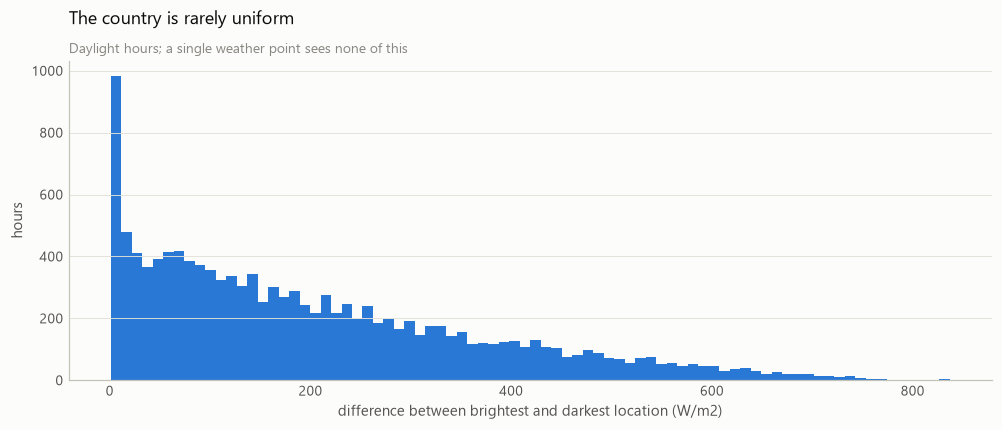

In [4]:
aggregates = {"ghi_mean", "ghi_min", "ghi_max", "ghi_stddev", "ghi_spread"}
locations = [c for c in mart.columns
             if c.startswith("ghi_") and c not in aggregates]

daylight = mart[mart["ghi_max"] > 0]
print(f"{len(locations)} sampled locations: {', '.join(sorted(locations))}")
print()
print(f"mean spread, brightest to darkest: {daylight['ghi_spread'].mean():.0f} W/m2")
print(f"largest spread observed         : {daylight['ghi_spread'].max():.0f} W/m2")

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(daylight["ghi_spread"], bins=80, color=style.BLUE)
ax.set_xlabel("difference between brightest and darkest location (W/m2)")
ax.set_ylabel("hours")
style.titled(ax, "The country is rarely uniform",
             "Daylight hours; a single weather point sees none of this")
style.save(fig, "regional_irradiance_spread")
plt.show()

## 4. How good is the day-ahead weather forecast?

Every weather column was issued a day before the hour it describes, which is the
lead a forecast gated at noon actually has.

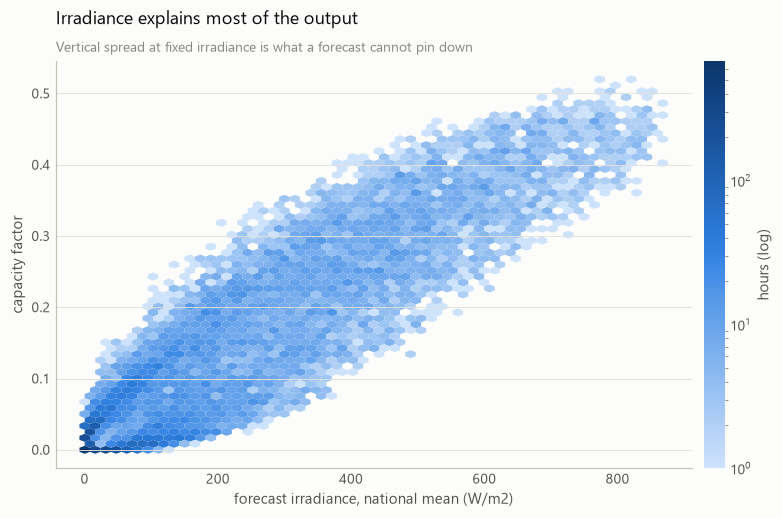

correlation with output: 0.9073


In [5]:
fig, ax = plt.subplots(figsize=(7, 4.6))
hexes = ax.hexbin(daylight["ghi_mean"], daylight["solar_capacity_factor"],
                  gridsize=55, bins="log", cmap=style.sequential_cmap(),
                  mincnt=1, linewidths=0)
ax.set_xlabel("forecast irradiance, national mean (W/m2)")
ax.set_ylabel("capacity factor")
style.titled(ax, "Irradiance explains most of the output",
             "Vertical spread at fixed irradiance is what a forecast cannot pin down")
bar = fig.colorbar(hexes, ax=ax, pad=0.02, label="hours (log)")
bar.outline.set_visible(False)
bar.ax.tick_params(length=0, labelsize=9)
style.save(fig, "irradiance_vs_output")
plt.show()

correlation = daylight["ghi_mean"].corr(daylight["solar_capacity_factor"])
print(f"correlation with output: {correlation:.4f}")

## 5. How hard is the problem?

Two weeks in June. Sun position is nearly identical across them, so any
variation is weather.

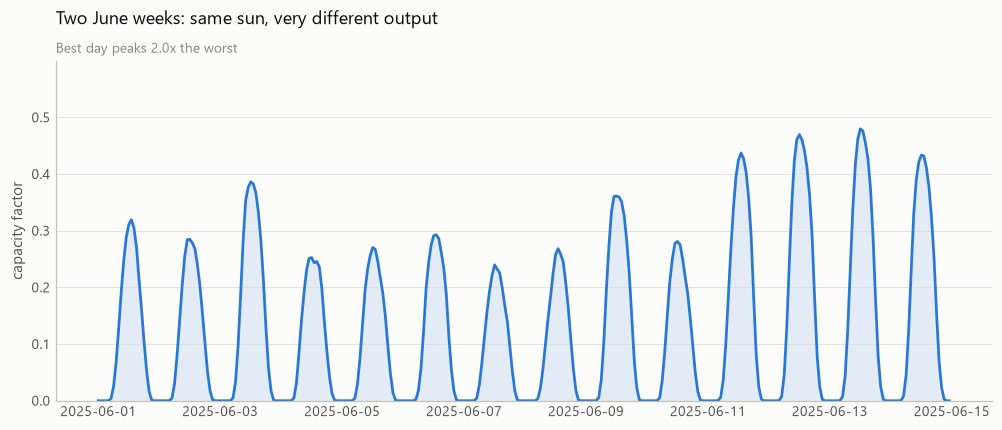

In [6]:
june = mart[(mart["local_datetime"] >= "2025-06-01")
            & (mart["local_datetime"] < "2025-06-15")]
style.require_data(june, "June 2025")

daily_peak = june.groupby(june["local_datetime"].dt.date)["solar_capacity_factor"].max()

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(june["local_datetime"], june["solar_capacity_factor"], color=style.BLUE)
ax.fill_between(june["local_datetime"], june["solar_capacity_factor"],
                color=style.BLUE, alpha=0.12, linewidth=0)
ax.set_ylim(0, june["solar_capacity_factor"].max() * 1.25)
ax.set_ylabel("capacity factor")
style.titled(ax, "Two June weeks: same sun, very different output",
             f"Best day peaks {daily_peak.max()/daily_peak.min():.1f}x the worst")
style.save(fig, "june_daily_variability")
plt.show()

## 6. The benchmark

`tso_solar_forecast_mw` is what the transmission operators published for the
same hour — a real operational forecast, not a naive baseline.

Scored on daylight hours only: output is exactly zero at night and every method
gets that right for free.

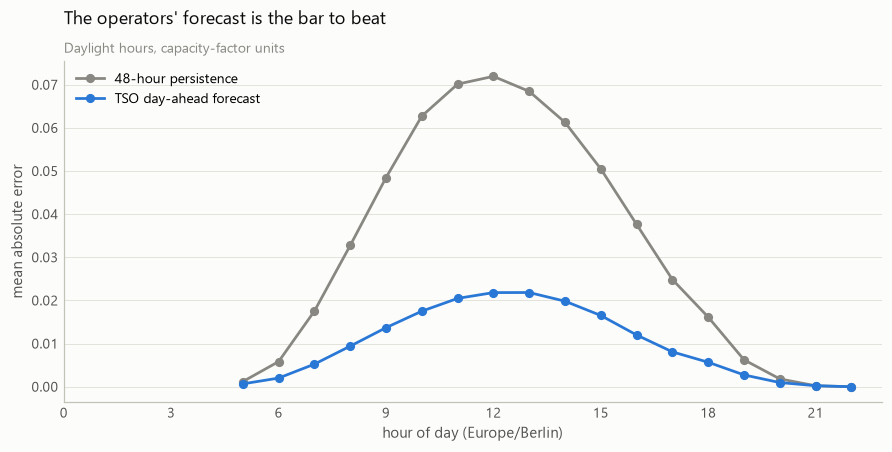

TSO forecast MAE     0.0126
48h persistence MAE  0.0409


In [7]:
scored = daylight[daylight["tso_solar_forecast_capacity_factor"].notna()
                  & daylight["capacity_factor_lag_48h"].notna()].copy()

scored["tso_error"] = (scored["tso_solar_forecast_capacity_factor"]
                       - scored["solar_capacity_factor"]).abs()
scored["lag_error"] = (scored["capacity_factor_lag_48h"]
                       - scored["solar_capacity_factor"]).abs()

by_hour = scored.groupby("hour_of_day")[["tso_error", "lag_error"]].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(by_hour.index, by_hour["lag_error"], color=style.INK_MUTED,
        marker="o", label="48-hour persistence")
ax.plot(by_hour.index, by_hour["tso_error"], color=style.BLUE,
        marker="o", label="TSO day-ahead forecast")
ax.set_xlabel("hour of day (Europe/Berlin)")
ax.set_ylabel("mean absolute error")
ax.set_xticks(range(0, 24, 3))
ax.legend(loc="upper left")
style.titled(ax, "The operators' forecast is the bar to beat",
             "Daylight hours, capacity-factor units")
style.save(fig, "tso_benchmark_by_hour")
plt.show()

print(f"TSO forecast MAE     {scored['tso_error'].mean():.4f}")
print(f"48h persistence MAE  {scored['lag_error'].mean():.4f}")

## 7. Prices

Not needed for the solar forecast, but they drive the battery optimiser.

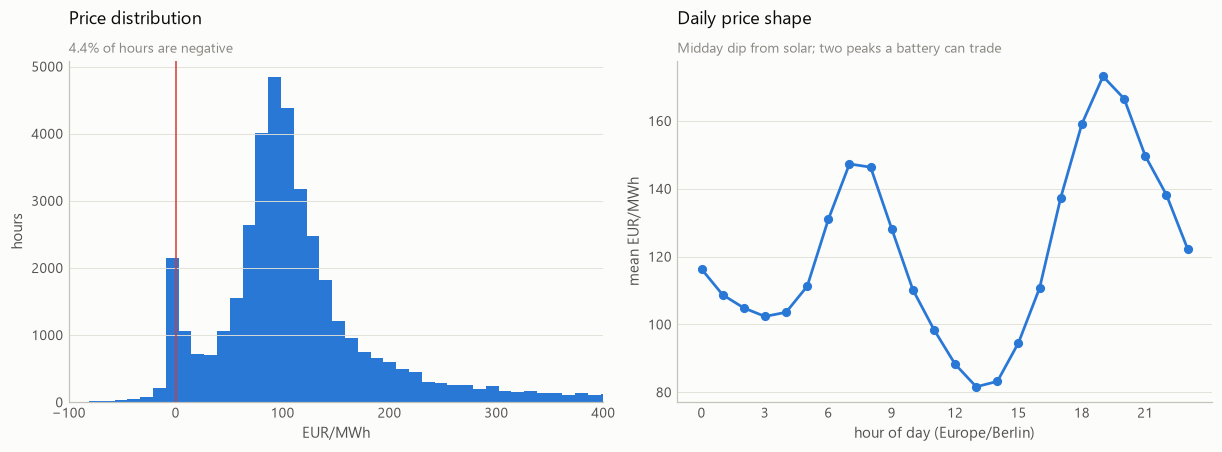

negative hours: 1,780 of 40,175
cheapest to dearest hour: 91.5 EUR/MWh


In [8]:
price = query(f'''
    SELECT utc_timestamp, price_eur_mwh,
           EXTRACT(HOUR FROM DATETIME(utc_timestamp, 'Europe/Berlin')) AS hour_of_day
    FROM `{PROJECT}.staging.stg_price`
    WHERE price_eur_mwh IS NOT NULL
''')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(price["price_eur_mwh"], bins=120, color=style.BLUE)
axes[0].axvline(0, color=style.CRITICAL, linewidth=1)
axes[0].set_xlabel("EUR/MWh")
axes[0].set_ylabel("hours")
axes[0].set_xlim(-100, 400)
negative_share = (price["price_eur_mwh"] < 0).mean()
style.titled(axes[0], "Price distribution",
             f"{negative_share:.1%} of hours are negative")

shape = price.groupby("hour_of_day")["price_eur_mwh"].mean()
axes[1].plot(shape.index, shape.to_numpy(), color=style.BLUE, marker="o")
axes[1].set_xlabel("hour of day (Europe/Berlin)")
axes[1].set_ylabel("mean EUR/MWh")
axes[1].set_xticks(range(0, 24, 3))
style.titled(axes[1], "Daily price shape",
             "Midday dip from solar; two peaks a battery can trade")
style.save(fig, "price_distribution_and_shape")
plt.show()

print(f"negative hours: {(price['price_eur_mwh'] < 0).sum():,} of {len(price):,}")
print(f"cheapest to dearest hour: {shape.max() - shape.min():.1f} EUR/MWh")

## What this establishes

| Finding | Consequence |
|---|---|
| Output is dominated by sun position | Calendar features are free; the problem is the deviation |
| Capacity climbs, capacity factor does not | Normalising by AC capacity was necessary |
| The country is rarely uniform | Nine weather points beat one by 43% |
| Consecutive June days differ severalfold | Weather is the whole problem |
| TSO forecast is ~3x better than persistence | The benchmark is a real bar |
| Negative prices with a strong daily shape | The battery optimiser has real arbitrage |

Next: `python -m smartgrid.tomorrow` forecasts the coming day and recommends a
battery schedule; `python -m smartgrid.score` measures saved forecasts against
what actually happened.